In [46]:
import pandas as pd
import ast
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [17]:
import torch_directml
import torch

# grabs your AMD GPU
device = torch_directml.device()
print("Using device:", device)

Using device: privateuseone:0


In [47]:

# 1) Hyper-parameters
MAX_VOCAB_SIZE = 20_000
MAX_SEQ_LEN    = 100
EMBED_DIM      = 128
BATCH_SIZE     = 64
LR             = 1e-3
EPOCHS         = 20
DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", DEVICE)


Using device: cpu


In [32]:
# 2) Load & preprocess
df = pd.read_csv("final.csv")
# Build vocabulary from tokenized tweets
#print("Building vocabulary...")
counter = {}
for row in df['tokenized_tweet']:
    for tok in ast.literal_eval(row):
        counter[tok] = counter.get(tok, 0) + 1
# Take most common tokens
sorted_tokens = sorted(counter.items(), key=lambda x: x[1], reverse=True)
most_common = sorted_tokens[:MAX_VOCAB_SIZE-2]
word2idx = {w: i+2 for i,(w,_) in enumerate(most_common)}
word2idx['<PAD>'] = 0
word2idx['<UNK>'] = 1
vocab_size = len(word2idx)
print(f"Vocabulary size: {vocab_size}")


Vocabulary size: 20000


In [28]:
# Encoder function
def encode(tokens):
    ids = [word2idx.get(t, 1) for t in tokens]
    if len(ids) > MAX_SEQ_LEN:
        return ids[:MAX_SEQ_LEN]
    return ids + [0] * (MAX_SEQ_LEN - len(ids))

# Apply encoding
df['input_ids'] = df['tokenized_tweet'] \
    .apply(ast.literal_eval) \
    .apply(encode)
labels = df['cyberbullying_type'].tolist()
inputs = df['input_ids'].tolist()

In [ ]:
print("Splitting data into train and test sets...")
X_train, X_test, y_train, y_test = train_test_split(
    inputs, labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)     # keeps the same ratio of each type in both sets


In [30]:
# 3) Dataset and DataLoader
def make_loader(X, y, batch_size, shuffle=False):
    class TweetDataset(Dataset):
        def __init__(self, X_data, y_data):
            # Ensure lists, not pandas Series
            X_list = X_data if isinstance(X_data, list) else X_data.tolist()
            y_list = y_data if isinstance(y_data, list) else y_data.tolist()
            self.X = torch.tensor(X_list, dtype=torch.long)
            self.y = torch.tensor(y_list, dtype=torch.long)
        def __len__(self): return len(self.y)
        def __getitem__(self, i): return self.X[i], self.y[i]
    ds = TweetDataset(X, y)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
test_loader  = make_loader(X_test,  y_test,  BATCH_SIZE, shuffle=False)

In [48]:
# 4) Define TextCNN model
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes,
                 kernel_sizes=[3,4,5], num_filters=100, dropout=0.5):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        x = self.embed(x)            # [B, L, E]
        x = x.permute(0,2,1)         # [B, E, L]
        pooled = []
        for conv in self.convs:
            c = torch.relu(conv(x))        # [B, F, L']
            p = torch.max(c, dim=2)[0]     # [B, F]
            pooled.append(p)
        cat = torch.cat(pooled, dim=1)    # [B, F * num_kernels]
        return self.fc(self.dropout(cat)) # [B, num_classes]

num_classes = len(set(labels))
model = TextCNN(vocab_size, EMBED_DIM, num_classes).to(DEVICE)
print(model)


TextCNN(
  (embed): Embedding(20000, 128, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(128, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(128, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(128, 100, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=300, out_features=6, bias=True)
)


In [49]:
# 5) Training setup
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

# 6) Training loop
print("Starting training...")
for epoch in range(1, EPOCHS+1):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch}/{EPOCHS} — Loss: {avg_loss:.4f}")


Starting training...
Epoch 1/20 — Loss: 0.7130
Epoch 2/20 — Loss: 0.4773
Epoch 3/20 — Loss: 0.4193
Epoch 4/20 — Loss: 0.3723
Epoch 5/20 — Loss: 0.3323
Epoch 6/20 — Loss: 0.2966
Epoch 7/20 — Loss: 0.2681
Epoch 8/20 — Loss: 0.2464
Epoch 9/20 — Loss: 0.2289
Epoch 10/20 — Loss: 0.2135
Epoch 11/20 — Loss: 0.1998
Epoch 12/20 — Loss: 0.1868
Epoch 13/20 — Loss: 0.1837
Epoch 14/20 — Loss: 0.1730
Epoch 15/20 — Loss: 0.1666
Epoch 16/20 — Loss: 0.1639
Epoch 17/20 — Loss: 0.1536
Epoch 18/20 — Loss: 0.1524
Epoch 19/20 — Loss: 0.1495
Epoch 20/20 — Loss: 0.1399


In [50]:
# 7) Evaluation
print("Evaluating on test set...")
model.eval()
y_pred, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        logits = model(X_batch)
        preds = logits.argmax(dim=1)
        y_pred.extend(preds.cpu().tolist())
        all_labels.extend(y_batch.cpu().tolist())

Evaluating on test set...



Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.47      0.49      1563
           1       0.93      0.94      0.94      1600
           2       0.94      0.97      0.95      1598
           3       0.97      0.98      0.97      1592
           4       0.85      0.85      0.85      1588
           5       0.55      0.59      0.57      1520

    accuracy                           0.80      9461
   macro avg       0.79      0.80      0.80      9461
weighted avg       0.80      0.80      0.80      9461



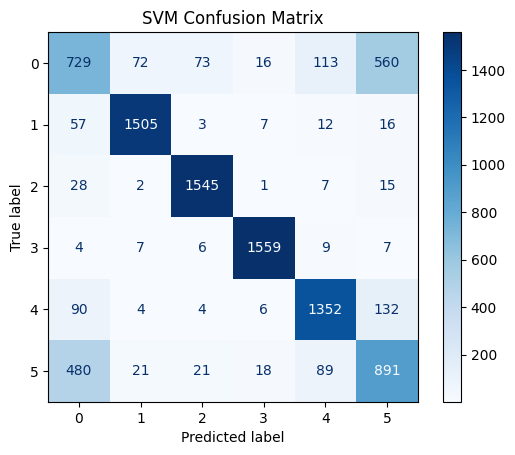

In [56]:
# label_map = {
#     'not_cyberbullying': 0,
#     'religion': 1,
#     'age': 2,
#     'ethnicity': 3,
#     'gender': 4,
#     'other_cyberbullying': 5
# }
print("\nClassification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)   
plt.title("SVM Confusion Matrix")
plt.show()